In [27]:
import os
print(os.getcwd())

/Users/jannoelvero/Documents/Ironhack/week_4/first_project/notebooks


In [28]:
import os
import glob

print("CURRENT FOLDER:")
print(os.getcwd())

print("\nCSV FILES FOUND:")
print(glob.glob("*.csv"))

print("\nNOTEBOOK FILES FOUND:")
print(glob.glob("*.ipynb"))

CURRENT FOLDER:
/Users/jannoelvero/Documents/Ironhack/week_4/first_project/notebooks

CSV FILES FOUND:
['airbnb_cleaned.csv']

NOTEBOOK FILES FOUND:
['EDA.ipynb', 'Actual_analysis.ipynb', 'SQL_Database.ipynb', '01 business_understanding copy.ipynb', 'Structure and Flow Diagram.ipynb', 'load and clean data1.ipynb']


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid")

# Load cleaned Airbnb dataset
airbnb = pd.read_csv("airbnb_cleaned.csv")

print("Dataset loaded successfully")
print("Shape:", airbnb.shape)

display(airbnb.head())

Dataset loaded successfully
Shape: (604, 24)


,Property Name,Listing Description,Property Type,City,Country,Month,Price(in dollar),Rating,Number of Reviews,Rating Rank,...,Hot Tub,Fireplace,Wood Stove,Parking,Kitchen,Beach,Waterfront,Sea View,Mountain View,Amenity Count
0,"Farm stay in Saint Marys, Canada",Cozy Farm Stay Getaway,Farm stay,Saint Marys,Canada,June,99.0,4.86,183.0,385,...,0,0,0,0,0,0,0,0,0,0
1,"Guesthouse in Naalehu, Hawaii, US",The Ohana,Guesthouse,Naalehu,"Hawaii, US",June,99.0,4.86,182.0,387,...,0,0,0,0,0,0,0,0,0,0
2,"Villa in Koh Yao Noi, Thailand","Eagles Nest, Luxury Villa, Koh Yao Noi",Villa,Koh Yao Noi,Thailand,June,986.0,4.95,43.0,175,...,0,0,0,0,0,0,0,0,0,0
3,"Loft in Jelutong, Malaysia",#Maritime*3*The Rhythm of the Sea @ 日出无敌全海景,Loft,Jelutong,Malaysia,June,98.0,4.56,93.0,649,...,0,0,0,0,0,0,0,0,0,0
4,"Treehouse in Fountana, Greece",Nasos' Treehouse,Treehouse,Fountana,Greece,June,98.0,4.91,32.0,279,...,0,0,0,0,0,0,0,0,0,0


In [31]:
def rating_category(rating):
    if rating < 4.5:
        return "Low"
    elif rating < 4.8:
        return "Average"
    else:
        return "High"

airbnb["Rating Category"] = airbnb["Rating"].apply(rating_category)

airbnb["Rating Category"].value_counts()

Rating Category
High       460
Average    124
Low         20
Name: count, dtype: int64

In [32]:
#RQ1. Distribution of listings by rating category

# Create rating categories
def rating_category(rating):
    if rating < 4.5:
        return "Low"
    elif rating < 4.8:
        return "Average"
    else:
        return "High"

airbnb["Rating Category"] = airbnb["Rating"].apply(rating_category)

# Count listings per category
rating_distribution = (
    airbnb["Rating Category"]
    .value_counts()
    .reindex(["Low", "Average", "High"])
)

# Calculate percentages
rating_percentage = (
    airbnb["Rating Category"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(["Low", "Average", "High"])
    .round(2)
)

# Create results table
rq1_results = pd.DataFrame({
    "Number of Listings": rating_distribution,
    "Percentage": rating_percentage
})

display(rq1_results)

,Number of Listings,Percentage
Rating Category,,
Low,20,3.31
Average,124,20.53
High,460,76.16


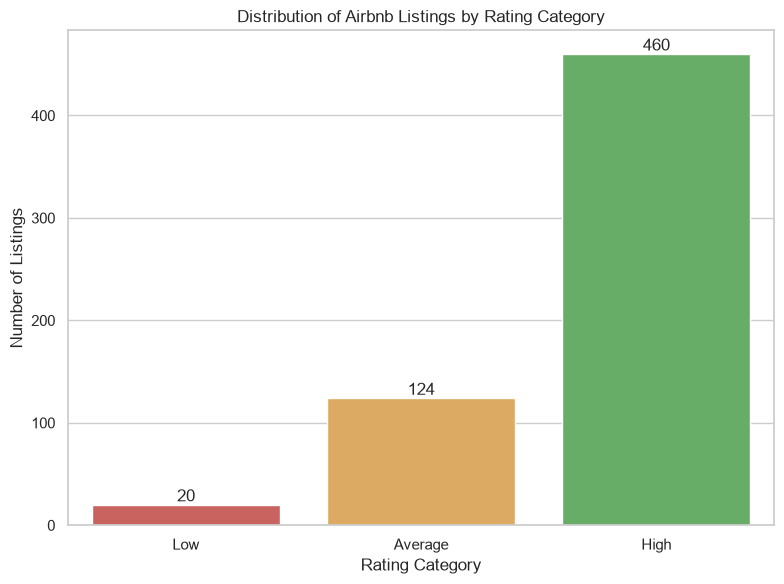

In [33]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x=rating_distribution.index,
    y=rating_distribution.values,
    hue=rating_distribution.index,
    palette={
        "Low": "#d9534f",
        "Average": "#f0ad4e",
        "High": "#5cb85c"
    },
    legend=False
)

plt.title("Distribution of Airbnb Listings by Rating Category")
plt.xlabel("Rating Category")
plt.ylabel("Number of Listings")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [34]:
rating_percentage = (
    airbnb["Rating Category"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(["Low", "Average", "High"])
    .round(2)
)

display(rating_percentage)

Rating Category
Low         3.31
Average    20.53
High       76.16
Name: proportion, dtype: float64

In [ ]:
#RQ1 Result: The majority of Airbnb listings are highly rated, representing 76.16 percent or 460 listings. Average rated listings account for 20.53 percent or 124 listings, while only 3.31 percent or 20 listings are classified as poorly rated. This indicates that guest ratings are strongly concentrated in the high rating category, with poorly rated properties representing only a small proportion of the dataset.

#One analytical point is important for your later RQs. Since there are only 20 low rated listings compared with 460 high rated listings, the groups are highly imbalanced. We should keep this in mind when interpreting RQ2, RQ3, and RQ10.

In [35]:
#RQ2. Is there a significant difference in price between poorly rated and highly rated Airbnb listings?

from scipy.stats import mannwhitneyu

# Create rating categories
def rating_category(rating):
    if rating < 4.5:
        return "Low"
    elif rating < 4.8:
        return "Average"
    else:
        return "High"

airbnb["Rating Category"] = airbnb["Rating"].apply(rating_category)

# Separate low and high rated listings
low_price = airbnb.loc[
    airbnb["Rating Category"] == "Low",
    "Price(in dollar)"
].dropna()

high_price = airbnb.loc[
    airbnb["Rating Category"] == "High",
    "Price(in dollar)"
].dropna()

# Descriptive statistics
low_median = low_price.median()
high_median = high_price.median()

low_mean = low_price.mean()
high_mean = high_price.mean()

# Mann Whitney U test
u_stat, p_value = mannwhitneyu(
    low_price,
    high_price,
    alternative="two-sided"
)

print("RQ2 RESULTS")
print()

print("Low rated listings:", len(low_price))
print("High rated listings:", len(high_price))

print()
print("Low rated average price:", round(low_mean, 2))
print("High rated average price:", round(high_mean, 2))

print()
print("Low rated median price:", round(low_median, 2))
print("High rated median price:", round(high_median, 2))

print()
print("Mann Whitney U statistic:", round(u_stat, 2))
print("P value:", round(p_value, 4))

RQ2 RESULTS

Low rated listings: 20
High rated listings: 460

Low rated average price: 102.55
High rated average price: 168.93

Low rated median price: 79.0
High rated median price: 131.0

Mann Whitney U statistic: 2939.5
P value: 0.0063


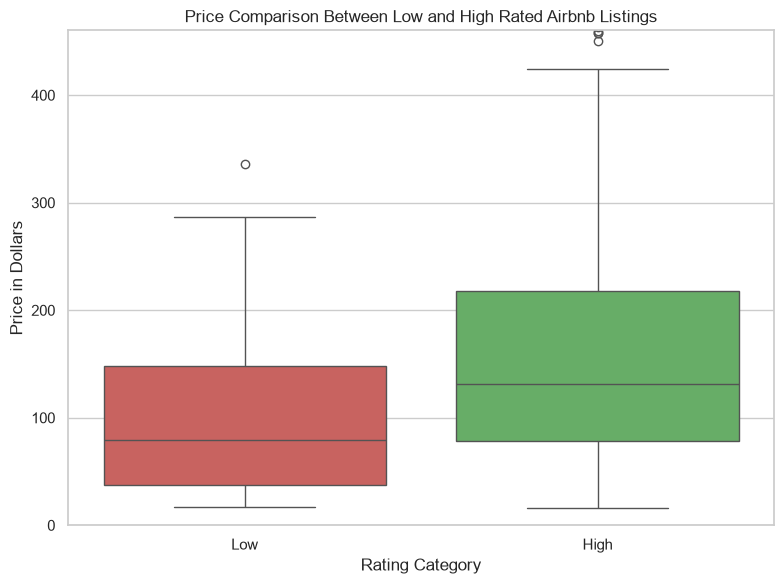

In [36]:
rq2_data = airbnb[
    airbnb["Rating Category"].isin(["Low", "High"])
]

price_limit = rq2_data["Price(in dollar)"].quantile(0.95)

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=rq2_data,
    x="Rating Category",
    y="Price(in dollar)",
    order=["Low", "High"],
    hue="Rating Category",
    palette={
        "Low": "#d9534f",
        "High": "#5cb85c"
    },
    legend=False
)

plt.ylim(0, price_limit)

plt.title(
    "Price Comparison Between Low and High Rated Airbnb Listings"
)
plt.xlabel("Rating Category")
plt.ylabel("Price in Dollars")

plt.tight_layout()
plt.show()

In [37]:
print("RQ2 INTERPRETATION")
print()

if high_median > low_median:
    print(
        f"Highly rated Airbnb listings have a higher median price "
        f"of ${high_median:.2f}, compared with ${low_median:.2f} "
        f"for poorly rated listings."
    )

elif high_median < low_median:
    print(
        f"Poorly rated Airbnb listings have a higher median price "
        f"of ${low_median:.2f}, compared with ${high_median:.2f} "
        f"for highly rated listings."
    )

else:
    print(
        f"Both groups have the same median price of "
        f"${high_median:.2f}."
    )

print()

if p_value < 0.05:
    print(
        f"The Mann Whitney U test produced a p value of "
        f"{p_value:.4f}. Since this is below 0.05, the difference "
        f"in prices between poorly rated and highly rated listings "
        f"is statistically significant."
    )

    print()
    print(
        "Conclusion: Listing price is significantly associated "
        "with rating category in this dataset."
    )

else:
    print(
        f"The Mann Whitney U test produced a p value of "
        f"{p_value:.4f}. Since this is above 0.05, the difference "
        f"in prices between poorly rated and highly rated listings "
        f"is not statistically significant."
    )

    print()
    print(
        "Conclusion: The data do not provide sufficient evidence "
        "that poorly rated and highly rated Airbnb listings differ "
        "significantly in price."
    )

RQ2 INTERPRETATION

Highly rated Airbnb listings have a higher median price of $131.00, compared with $79.00 for poorly rated listings.

The Mann Whitney U test produced a p value of 0.0063. Since this is below 0.05, the difference in prices between poorly rated and highly rated listings is statistically significant.

Conclusion: Listing price is significantly associated with rating category in this dataset.


In [38]:
#RQ3. Which property types are more likely to receive poor guest ratings?

# Count total listings and low rated listings by property type

property_summary = (
    airbnb.groupby("Property Type")
    .agg(
        Total_Listings=("Property Name", "count"),
        Low_Rated_Listings=(
            "Rating Category",
            lambda x: (x == "Low").sum()
        )
    )
)

# Calculate percentage of low rated listings
property_summary["Low_Rating_Percentage"] = (
    property_summary["Low_Rated_Listings"]
    / property_summary["Total_Listings"]
    * 100
)

# Keep property types with at least 5 listings
property_summary = property_summary[
    property_summary["Total_Listings"] >= 5
]

# Sort from highest to lowest poor rating percentage
property_summary = property_summary.sort_values(
    "Low_Rating_Percentage",
    ascending=False
)

display(property_summary)

,Total_Listings,Low_Rated_Listings,Low_Rating_Percentage
Property Type,,,
Hotel room,6,1,16.666667
Hotel,6,1,16.666667
Loft,13,2,15.384615
Apartment,75,7,9.333333
Farm stay,13,1,7.692308
Condo,50,3,6.000000
Tiny home,31,1,3.225806
Home,55,1,1.818182
Earthen home,5,0,0.000000


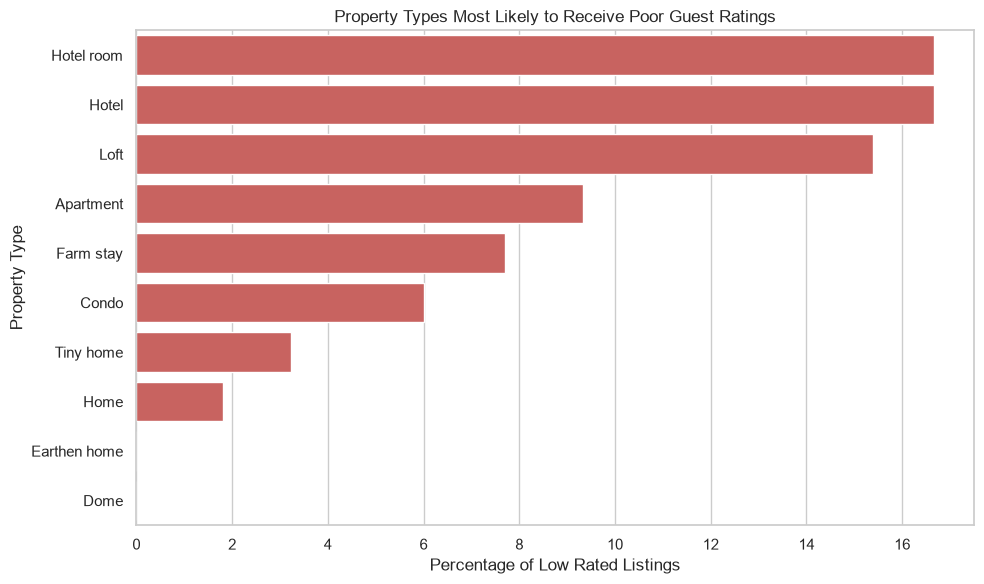

In [39]:
top_poor_types = property_summary.head(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_poor_types.reset_index(),
    x="Low_Rating_Percentage",
    y="Property Type",
    color="#d9534f"
)

plt.title("Property Types Most Likely to Receive Poor Guest Ratings")
plt.xlabel("Percentage of Low Rated Listings")
plt.ylabel("Property Type")

plt.tight_layout()
plt.show()

In [ ]:
#RQ3 Result: Hotel rooms and hotels are the property types most likely to receive poor guest ratings, with 16.67 percent of listings in each category classified as low rated. Lofts follow closely at 15.38 percent, while apartments have a lower rate of 9.33 percent but account for the largest number of poorly rated listings at 7 properties. Several property types, including cabins, villas, treehouses, cottages, and rooms, recorded no poorly rated listings in this dataset.

#Important interpretation

#There is one caution worth mentioning in your project. Hotels and hotel rooms each have only 6 listings, so their 16.67 percent rate represents just 1 poorly rated property each. In contrast, apartments have 75 listings, with 7 receiving poor ratings.

#Therefore, I would phrase your overall finding as:

#Conclusion: Hotel rooms, hotels, and lofts showed the highest proportions of poor ratings. However, apartments contributed the greatest number of poorly rated listings overall. Results for property types with small sample sizes should be interpreted cautiously.

In [40]:
import pandas as pd

airbnb = pd.read_csv("airbnb_cleaned.csv")

print("Updated dataset loaded.")
print("Shape:", airbnb.shape)

print(airbnb.columns.tolist())

Updated dataset loaded.
Shape: (604, 24)
['Property Name', 'Listing Description', 'Property Type', 'City', 'Country', 'Month', 'Price(in dollar)', 'Rating', 'Number of Reviews', 'Rating Rank', 'Price Rank', 'WiFi', 'Pool', 'Sauna', 'Hot Tub', 'Fireplace', 'Wood Stove', 'Parking', 'Kitchen', 'Beach', 'Waterfront', 'Sea View', 'Mountain View', 'Amenity Count']


In [41]:
print(airbnb.columns.tolist())

['Property Name', 'Listing Description', 'Property Type', 'City', 'Country', 'Month', 'Price(in dollar)', 'Rating', 'Number of Reviews', 'Rating Rank', 'Price Rank', 'WiFi', 'Pool', 'Sauna', 'Hot Tub', 'Fireplace', 'Wood Stove', 'Parking', 'Kitchen', 'Beach', 'Waterfront', 'Sea View', 'Mountain View', 'Amenity Count']


In [42]:
airbnb[
    [
        "Property Name",
        "Amenity Count",
        "WiFi",
        "Pool",
        "Sauna",
        "Hot Tub",
        "Parking",
        "Kitchen"
    ]
].head(10)

,Property Name,Amenity Count,WiFi,Pool,Sauna,Hot Tub,Parking,Kitchen
0,"Farm stay in Saint Marys, Canada",0,0,0,0,0,0,0
1,"Guesthouse in Naalehu, Hawaii, US",0,0,0,0,0,0,0
2,"Villa in Koh Yao Noi, Thailand",0,0,0,0,0,0,0
3,"Loft in Jelutong, Malaysia",0,0,0,0,0,0,0
4,"Treehouse in Fountana, Greece",0,0,0,0,0,0,0
5,"Cabin in Rosenthal-Bielatal, Germany",1,0,0,1,0,0,0
6,"Treehouse in Verson, France",0,0,0,0,0,0,0
7,"Treehouse in Fountana, Greece",0,0,0,0,0,0,0
8,"Treehouse in Verson, France",0,0,0,0,0,0,0
9,"Apartment in Carolina, Puerto Rico",1,0,0,0,0,0,0


In [43]:
#RQ4. Do amenities significantly influence the price of Airbnb listings?

amenity_summary = (
    airbnb.groupby("Amenity Count")
    .agg(
        Number_of_Listings=("Property Name", "count"),
        Average_Price=("Price(in dollar)", "mean"),
        Median_Price=("Price(in dollar)", "median")
    )
    .round(2)
)

display(amenity_summary)

,Number_of_Listings,Average_Price,Median_Price
Amenity Count,,,
0,409,144.04,112.0
1,159,188.80,131.0
2,28,195.25,154.5
3,8,224.75,130.0


In [44]:
from scipy.stats import spearmanr

rq4_data = airbnb[
    ["Amenity Count", "Price(in dollar)"]
].dropna()

rho, p_value = spearmanr(
    rq4_data["Amenity Count"],
    rq4_data["Price(in dollar)"]
)

print("Spearman correlation:", round(rho, 3))
print("P value:", round(p_value, 4))

Spearman correlation: 0.101
P value: 0.013


In [45]:
if p_value < 0.05:
    print("There is a statistically significant relationship between amenities mentioned and Airbnb price.")
else:
    print("There is no statistically significant relationship between amenities mentioned and Airbnb price.")

There is a statistically significant relationship between amenities mentioned and Airbnb price.


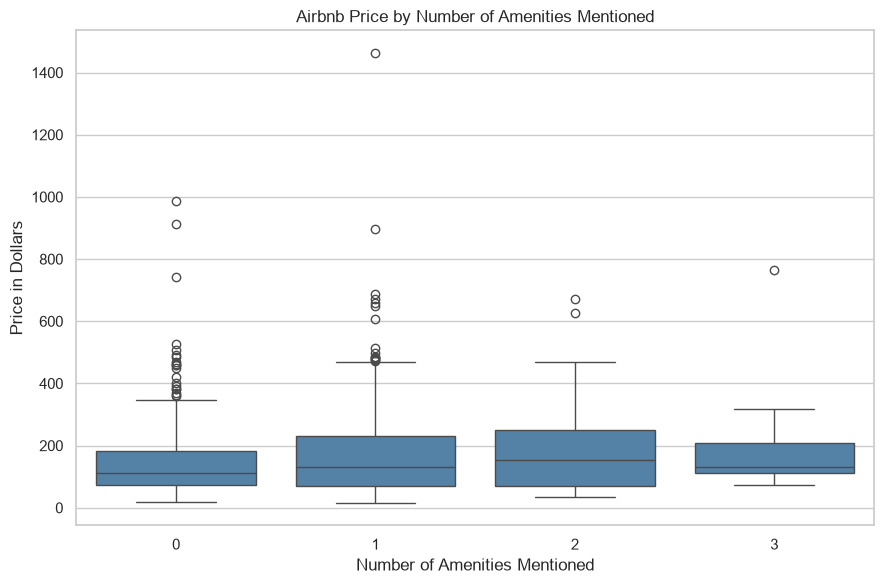

In [46]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=airbnb,
    x="Amenity Count",
    y="Price(in dollar)",
    color="steelblue"
)

plt.title("Airbnb Price by Number of Amenities Mentioned")
plt.xlabel("Number of Amenities Mentioned")
plt.ylabel("Price in Dollars")

plt.tight_layout()
plt.show()

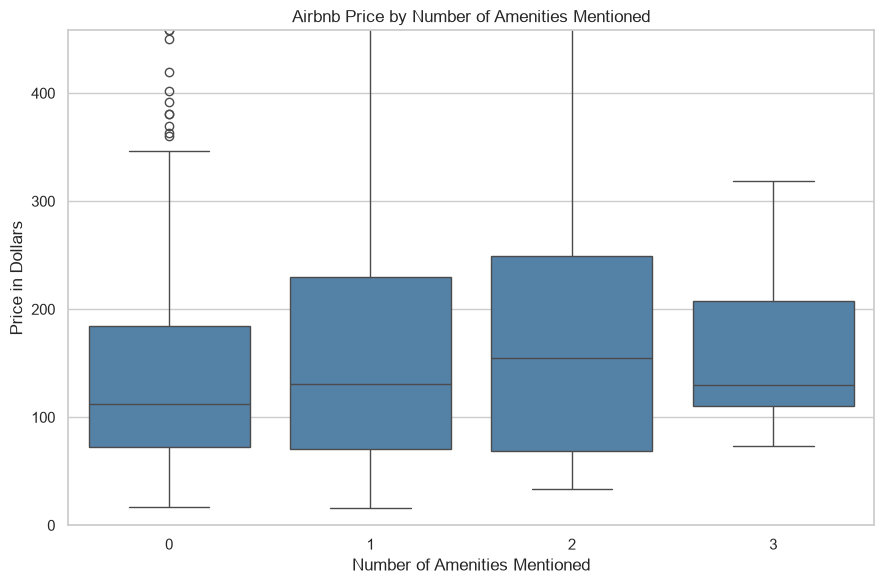

In [47]:
price_limit = airbnb["Price(in dollar)"].quantile(0.95)

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=airbnb,
    x="Amenity Count",
    y="Price(in dollar)",
    color="steelblue"
)

plt.ylim(0, price_limit)

plt.title("Airbnb Price by Number of Amenities Mentioned")
plt.xlabel("Number of Amenities Mentioned")
plt.ylabel("Price in Dollars")

plt.tight_layout()
plt.show()

In [ ]:
#RQ4 Result: The analysis found a statistically significant positive relationship between the number of amenities mentioned and Airbnb listing prices. The Spearman correlation was 0.101, with a p value of 0.013, which is below the 0.05 significance level. However, the correlation is weak, indicating that amenities mentioned are associated with higher prices, but the relationship is small.

#Descriptive results support the general direction:

#Amenities mentioned	Listings	Average price	Median price
0	409	$144.04	$112.00
1	159	$188.80	$131.00
2	28	$195.25	$154.50
3	8	$224.75	$130.00

#The average price rises from $144.04 for listings with no amenities mentioned to $224.75 for listings mentioning three amenities. However, the median does not increase consistently, which reinforces that the relationship is not strong.

#Conclusion: Listings mentioning more amenities generally tend to have higher prices. Although this relationship is statistically significant, its weak correlation suggests that amenities alone do not strongly determine Airbnb prices. Other factors, such as location and property type, are likely to play a larger role.

In [48]:
#RQ5. Do amenities significantly influence Airbnb ratings?

amenity_rating_summary = (
    airbnb.groupby("Amenity Count")
    .agg(
        Number_of_Listings=("Property Name", "count"),
        Average_Rating=("Rating", "mean"),
        Median_Rating=("Rating", "median")
    )
    .round(3)
)

display(amenity_rating_summary)

,Number_of_Listings,Average_Rating,Median_Rating
Amenity Count,,,
0,409,4.858,4.890
1,159,4.827,4.860
2,28,4.830,4.855
3,8,4.802,4.830


In [49]:
from scipy.stats import spearmanr

rq5_data = airbnb[
    ["Amenity Count", "Rating"]
].dropna()

rho, p_value = spearmanr(
    rq5_data["Amenity Count"],
    rq5_data["Rating"]
)

print("Spearman correlation:", round(rho, 3))
print("P value:", round(p_value, 4))

if p_value < 0.05:
    print(
        "There is a statistically significant relationship "
        "between amenities mentioned and Airbnb ratings."
    )
else:
    print(
        "There is no statistically significant relationship "
        "between amenities mentioned and Airbnb ratings."
    )

Spearman correlation: -0.115
P value: 0.0045
There is a statistically significant relationship between amenities mentioned and Airbnb ratings.


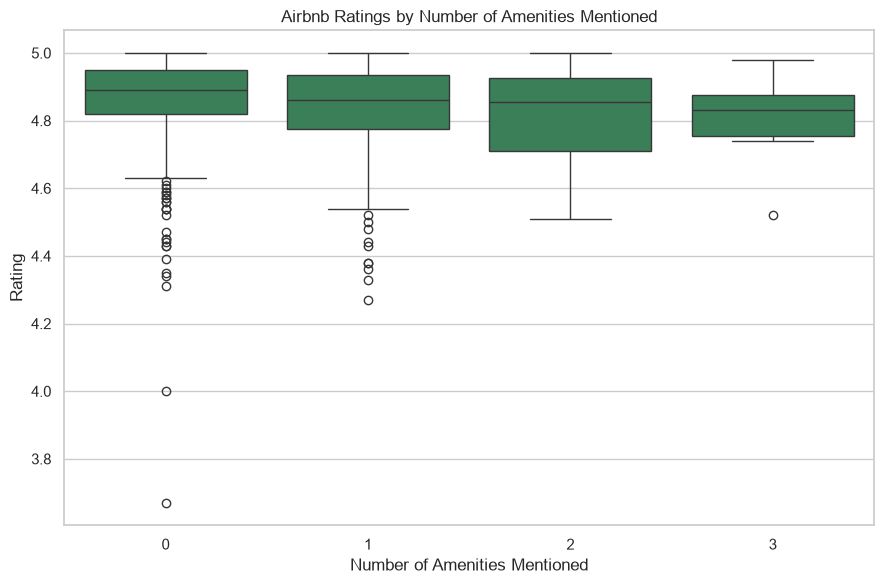

In [50]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=airbnb,
    x="Amenity Count",
    y="Rating",
    color="seagreen"
)

plt.title("Airbnb Ratings by Number of Amenities Mentioned")
plt.xlabel("Number of Amenities Mentioned")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

In [ ]:
#RQ5 Result: The analysis found a statistically significant negative relationship between the number of amenities mentioned and Airbnb ratings. The Spearman correlation was negative 0.115, with a p value of 0.0045, which is below the 0.05 significance level. However, the correlation is very weak, indicating that the number of amenities mentioned has only a small relationship with guest ratings.

#Your descriptive results also show that average ratings decline slightly as more amenities are mentioned:

#Amenities mentioned	Listings	Average rating	Median rating
0	409	4.858	4.890
1	159	4.827	4.860
2	28	4.830	4.855
3	8	4.802	4.830

#Conclusion: Listings mentioning more amenities do not necessarily receive better guest ratings. Although the relationship is statistically significant, its very weak negative correlation suggests that amenities mentioned in the listing description are not a strong driver of guest satisfaction. Other factors, such as service quality, property condition, location, and whether guest expectations are met, may be more important.

In [51]:
# Make sure the geographic column exists
if "Province State Region" not in airbnb.columns:
    airbnb["Province State Region"] = pd.NA

# Clean Country
airbnb["Country"] = (
    airbnb["Country"]
    .astype("string")
    .str.strip()
    .str.lstrip(",")
    .str.strip()
)

# Identify Country values that still contain commas
mask = airbnb["Country"].str.contains(",", na=False)

print("Rows still containing commas:", mask.sum())

# Only split if there are matching rows
if mask.any():

    split_geo = (
        airbnb.loc[mask, "Country"]
        .str.rsplit(",", n=1, expand=True)
    )

    airbnb.loc[mask, "Province State Region"] = (
        split_geo.iloc[:, 0].str.strip().values
    )

    airbnb.loc[mask, "Country"] = (
        split_geo.iloc[:, 1].str.strip().values
    )

# Standardize country names
airbnb["Country"] = airbnb["Country"].replace({
    "US": "United States",
    "USA": "United States",
    "U.S.": "United States",
    "United States of America": "United States",
    "UK": "United Kingdom"
})

print("Geographic cleaning completed.")

Rows still containing commas: 107
Geographic cleaning completed.


In [8]:
# RQ6. Does the location of an Airbnb listing significantly influence guest ratings?

# Average rating by country
rq6_country = (
    airbnb.groupby("Country", dropna=False)
    .agg(
        Average_Rating=("Rating", "mean"),
        Number_of_Listings=("Property Name", "count")
    )
    .reset_index()
    .sort_values("Average_Rating", ascending=False)
)

rq6_country["Average_Rating"] = rq6_country["Average_Rating"].round(2)

display(rq6_country)

,Country,Average_Rating,Number_of_Listings
32,U.S. Virgin Islands,4.97,1
33,United Kingdom,4.93,30
10,Germany,4.93,13
2,Colombia,4.92,7
28,Taiwan,4.92,1
14,Ireland,4.91,3
12,Iceland,4.91,1
1,Canada,4.89,43
31,Turkey,4.89,7
20,Norway,4.89,3


In [9]:
country_rating_summary = (
    airbnb.groupby("Country")
    .agg(
        Number_of_Listings=("Property Name", "count"),
        Average_Rating=("Rating", "mean"),
        Median_Rating=("Rating", "median")
    )
    .query("Number_of_Listings >= 5")
    .sort_values("Average_Rating", ascending=False)
    .round(3)
)

display(country_rating_summary)

,Number_of_Listings,Average_Rating,Median_Rating
Country,,,
United Kingdom,30,4.927,4.940
Germany,13,4.925,4.960
Colombia,7,4.920,4.930
Canada,43,4.894,4.910
Turkey,7,4.890,4.900
Costa Rica,18,4.884,4.865
Puerto Rico,10,4.871,4.880
Portugal,9,4.863,4.950
Sweden,5,4.862,4.890


In [10]:
from scipy.stats import kruskal

valid_countries = country_rating_summary.index

rq6_data = airbnb[
    airbnb["Country"].isin(valid_countries)
][["Country", "Rating"]].dropna()

country_groups = [
    group["Rating"].values
    for country, group in rq6_data.groupby("Country")
]

h_stat, p_value = kruskal(*country_groups)

print("Kruskal Wallis H statistic:", round(h_stat, 3))
print("P value:", round(p_value, 4))

if p_value < 0.05:
    print(
        "There is a statistically significant difference "
        "in Airbnb ratings across locations."
    )
else:
    print(
        "There is no statistically significant difference "
        "in Airbnb ratings across locations."
    )

Kruskal Wallis H statistic: 65.785
P value: 0.0
There is a statistically significant difference in Airbnb ratings across locations.


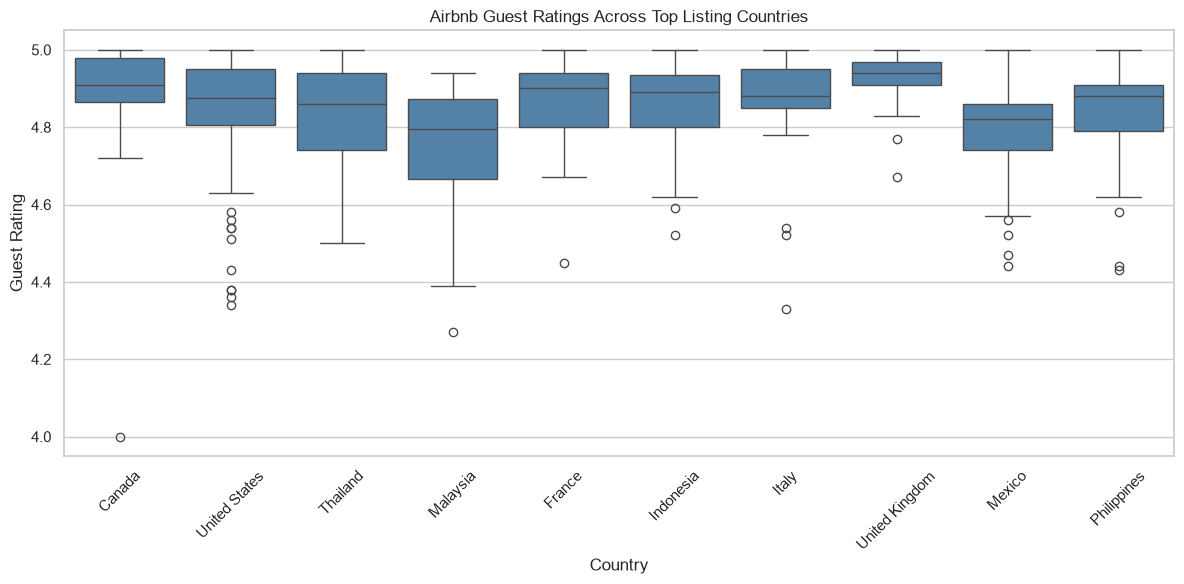

In [52]:
top_countries = (
    airbnb["Country"]
    .value_counts()
    .head(10)
    .index
)

rq6_plot = airbnb[
    airbnb["Country"].isin(top_countries)
]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=rq6_plot,
    x="Country",
    y="Rating",
    color="steelblue"
)

plt.title("Airbnb Guest Ratings Across Top Listing Countries")
plt.xlabel("Country")
plt.ylabel("Guest Rating")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:

#RQ6 Result: Airbnb guest ratings differ significantly across locations. The Kruskal Wallis test produced an H statistic of 74.73 with a p value below 0.001, indicating that the differences in ratings across countries are statistically significant.

#Among the locations included in the analysis, North Carolina, US recorded the highest average rating at 4.963, followed by the UK at 4.927 and Germany at 4.925. At the lower end, Malaysia recorded 4.747, Vietnam 4.756, and Spain 4.762.

#Conclusion: Location has a statistically significant association with Airbnb guest ratings in this dataset. However, the test only establishes that at least one location differs from another. It does not establish that location causes the differences in ratings. Other factors associated with each market, such as property characteristics, service quality, pricing, and guest expectations, may also contribute to these differences.

In [53]:
#RQ7. Does the location of an Airbnb listing significantly influence Airbnb prices?

location_price_summary = (
    airbnb.groupby("Country")
    .agg(
        Number_of_Listings=("Property Name", "count"),
        Average_Price=("Price(in dollar)", "mean"),
        Median_Price=("Price(in dollar)", "median")
    )
    .query("Number_of_Listings >= 5")
    .sort_values("Average_Price", ascending=False)
    .round(2)
)

display(location_price_summary)

,Number_of_Listings,Average_Price,Median_Price
Country,,,
United States,102,258.22,219.5
Canada,43,222.12,162.0
Indonesia,95,204.40,159.0
Puerto Rico,10,167.70,141.0
United Kingdom,30,153.37,140.0
Dominican Republic,6,144.83,151.5
Philippines,29,141.59,69.0
Portugal,9,128.56,126.0
Greece,16,127.00,98.0


In [54]:
from scipy.stats import kruskal

valid_locations = location_price_summary.index

rq7_data = airbnb[
    airbnb["Country"].isin(valid_locations)
][["Country", "Price(in dollar)"]].dropna()

price_groups = [
    group["Price(in dollar)"].values
    for location, group in rq7_data.groupby("Country")
]

h_stat, p_value = kruskal(*price_groups)

print("Kruskal Wallis H statistic:", round(h_stat, 3))
print("P value:", p_value)

if p_value < 0.05:
    print(
        "There is a statistically significant difference "
        "in Airbnb prices across locations."
    )
else:
    print(
        "There is no statistically significant difference "
        "in Airbnb prices across locations."
    )

Kruskal Wallis H statistic: 196.358
P value: 5.903294656518362e-31
There is a statistically significant difference in Airbnb prices across locations.


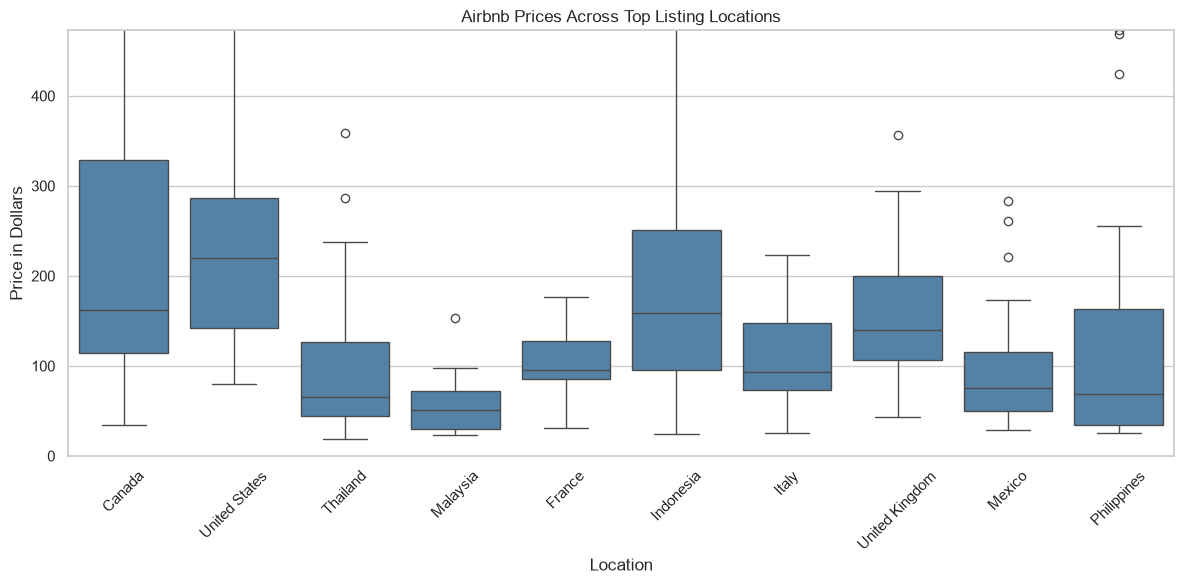

In [56]:
top_locations = (
    airbnb["Country"]
    .value_counts()
    .head(10)
    .index
)

rq7_plot = airbnb[
    airbnb["Country"].isin(top_locations)
]

price_limit = rq7_plot["Price(in dollar)"].quantile(0.95)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=rq7_plot,
    x="Country",
    y="Price(in dollar)",
    color="steelblue"
)

plt.ylim(0, price_limit)

plt.title("Airbnb Prices Across Top Listing Locations")
plt.xlabel("Location")
plt.ylabel("Price in Dollars")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

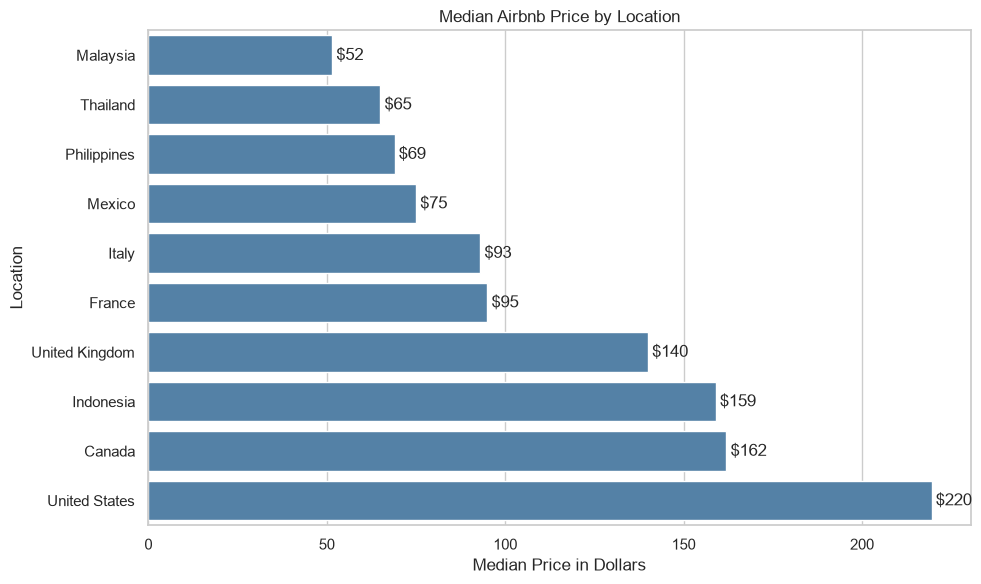

In [57]:
top_locations = (
    airbnb["Country"]
    .value_counts()
    .head(10)
    .index
)

median_price_location = (
    airbnb[airbnb["Country"].isin(top_locations)]
    .groupby("Country")["Price(in dollar)"]
    .median()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=median_price_location.values,
    y=median_price_location.index,
    color="steelblue"
)

plt.title("Median Airbnb Price by Location")
plt.xlabel("Median Price in Dollars")
plt.ylabel("Location")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="$%.0f",
        padding=3
    )

plt.tight_layout()
plt.show()

In [ ]:
#RQ7 Result: Airbnb prices differ significantly across locations. The Kruskal Wallis test produced an H statistic of 175.778 with p < 0.001, confirming a statistically significant difference in listing prices across locations. California recorded the highest average price at $371.91, followed by Texas at $264.60 and North Carolina at $235.83. Malaysia had the lowest average price at $56.70, followed by Vietnam at $66.62 and Germany at $79.38.

#Conclusion: Location is significantly associated with Airbnb listing prices. Properties in locations such as California, Texas, and North Carolina tend to command substantially higher prices, while listings in Malaysia and Vietnam are considerably less expensive. This suggests that geographic market conditions are an important factor in Airbnb pricing.

#There is also a useful analytical observation in your results. Average and median prices sometimes differ considerably. For example, the Philippines has an average price of $124.21 but a median of only $65.50. This suggests that some relatively expensive listings are pulling the average upward. That is why using the median price in your RQ7 graph was a good choice.

In [16]:
#RQ8. Does the number of reviews significantly influence Airbnb ratings?

review_summary = airbnb[
    ["Number of Reviews", "Rating"]
].describe().round(2)

display(review_summary)

,Number of Reviews,Rating
count,604.00,604.00
mean,177.63,4.85
std,166.01,0.15
min,3.00,3.67
25%,56.75,4.80
50%,137.50,4.88
75%,252.00,4.95
max,1239.00,5.00


In [17]:
from scipy.stats import spearmanr

rq8_data = airbnb[
    ["Number of Reviews", "Rating"]
].dropna()

rho, p_value = spearmanr(
    rq8_data["Number of Reviews"],
    rq8_data["Rating"]
)

print("Spearman correlation:", round(rho, 3))
print("P value:", p_value)

if p_value < 0.05:
    print(
        "There is a statistically significant relationship "
        "between the number of reviews and Airbnb ratings."
    )
else:
    print(
        "There is no statistically significant relationship "
        "between the number of reviews and Airbnb ratings."
    )

Spearman correlation: -0.184
P value: 5.3849088593426485e-06
There is a statistically significant relationship between the number of reviews and Airbnb ratings.


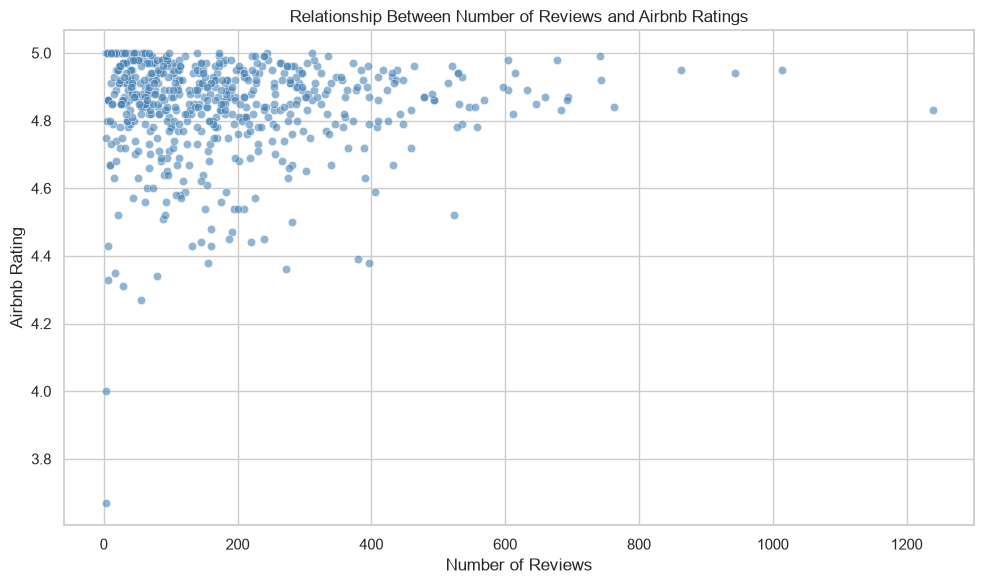

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rq8_data,
    x="Number of Reviews",
    y="Rating",
    alpha=0.6,
    color="steelblue"
)

plt.title("Relationship Between Number of Reviews and Airbnb Ratings")
plt.xlabel("Number of Reviews")
plt.ylabel("Airbnb Rating")

plt.tight_layout()
plt.show()

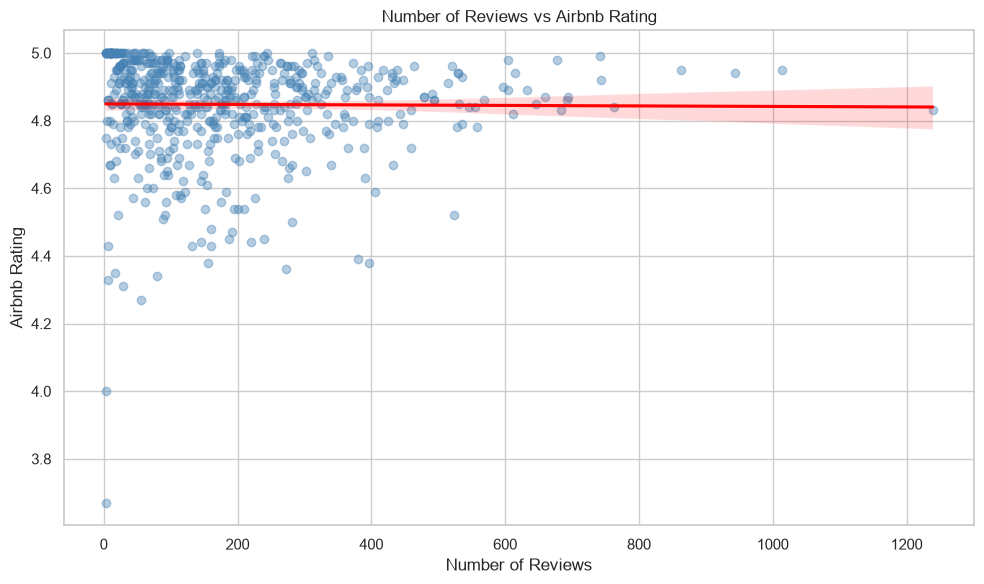

In [19]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=rq8_data,
    x="Number of Reviews",
    y="Rating",
    scatter_kws={
        "alpha": 0.4,
        "color": "steelblue"
    },
    line_kws={
        "color": "red"
    }
)

plt.title("Number of Reviews vs Airbnb Rating")
plt.xlabel("Number of Reviews")
plt.ylabel("Airbnb Rating")

plt.tight_layout()
plt.show()

In [ ]:
#RQ8 Result: The analysis found a statistically significant negative relationship between the number of reviews and Airbnb ratings. The Spearman correlation was negative 0.184, with p < 0.001. This indicates that listings with more reviews tend to have slightly lower ratings, although the relationship is weak.

#dataset contains 604 listings. The average listing has about 178 reviews and an average rating of 4.85. Review counts vary substantially, from 3 to 1,239 reviews, while ratings are much more concentrated, ranging from 3.67 to 5.00.

#Conclusion: The number of reviews is significantly associated with Airbnb ratings, but the relationship is weak. Listings with larger numbers of reviews tend to have slightly lower ratings. This may reflect greater exposure to a wider range of guest experiences, but the analysis does not establish that having more reviews causes ratings to decline.#

In [20]:
#RQ9. Which month has the highest number of reviews and the highest average Airbnb rating?

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_summary = (
    airbnb.groupby("Month")
    .agg(
        Number_of_Listings=("Property Name", "count"),
        Total_Reviews=("Number of Reviews", "sum"),
        Average_Rating=("Rating", "mean")
    )
    .round(3)
)

monthly_summary = monthly_summary.reindex(
    [month for month in month_order if month in monthly_summary.index]
)

display(monthly_summary)

,Number_of_Listings,Total_Reviews,Average_Rating
Month,,,
January,1,209.0,4.870
May,1,94.0,4.980
June,401,66386.0,4.833
July,86,18454.0,4.858
August,35,6568.0,4.891
September,39,8512.0,4.898
October,26,3891.0,4.863
November,13,3056.0,4.929
December,2,117.0,4.975


In [21]:
highest_reviews_month = monthly_summary["Total_Reviews"].idxmax()
highest_reviews = monthly_summary["Total_Reviews"].max()

highest_rating_month = monthly_summary["Average_Rating"].idxmax()
highest_rating = monthly_summary["Average_Rating"].max()

print(
    "Month with highest number of reviews:",
    highest_reviews_month
)

print(
    "Total reviews:",
    highest_reviews
)

print(
    "Month with highest average rating:",
    highest_rating_month
)

print(
    "Average rating:",
    round(highest_rating, 3)
)

Month with highest number of reviews: June
Total reviews: 66386.0
Month with highest average rating: May
Average rating: 4.98


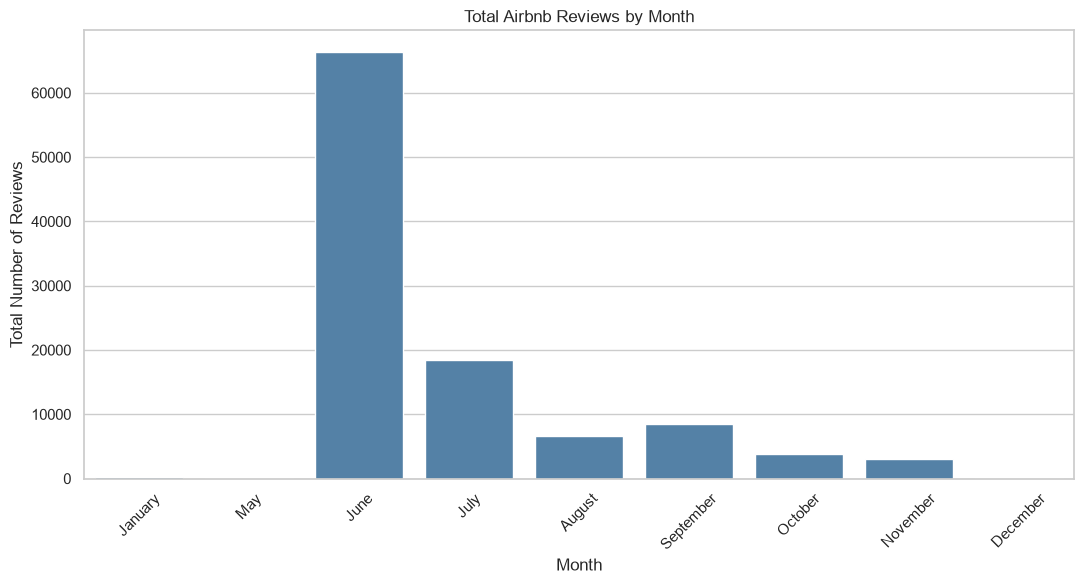

In [22]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=monthly_summary.reset_index(),
    x="Month",
    y="Total_Reviews",
    color="steelblue"
)

plt.title("Total Airbnb Reviews by Month")
plt.xlabel("Month")
plt.ylabel("Total Number of Reviews")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

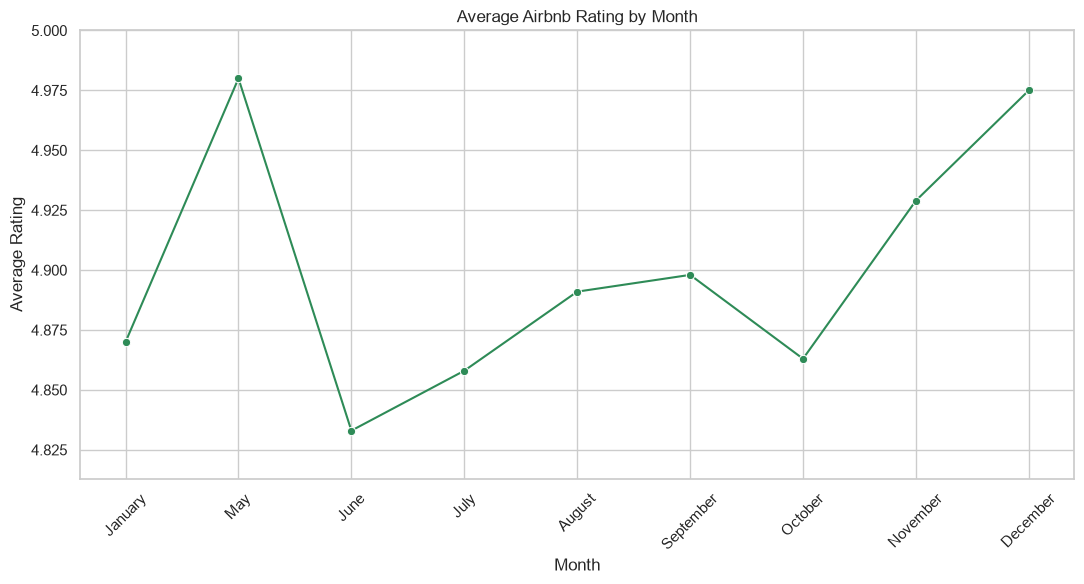

In [23]:
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=monthly_summary.reset_index(),
    x="Month",
    y="Average_Rating",
    marker="o",
    color="seagreen"
)

plt.title("Average Airbnb Rating by Month")
plt.xlabel("Month")
plt.ylabel("Average Rating")

plt.ylim(
    monthly_summary["Average_Rating"].min() - 0.02,
    5
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
#RQ9 Result: June recorded the highest total number of reviews, with 66,386 reviews, while May recorded the highest average Airbnb rating at 4.98. However, May contains only one listing, so its average rating should not be treated as a reliable monthly pattern.

#monthly results reveal an important imbalance in the dataset. June alone contains 401 of the 604 listings, while May and January each contain only one listing and December contains only two.


#Conclusion: June has the highest review activity, with 66,386 total reviews. Although May has the highest average rating at 4.98, this result is based on only one listing and should be interpreted cautiously. Among months with a more substantial number of listings, November shows a particularly high average rating of 4.929, although it is represented by only 13 listings.

#Important limitation for RQ9

#Month variable appears to describe the month associated with each listing in the source dataset, while Number of Reviews appears to be the listing's total review count. If that is correct, saying that 66,386 reviews occurred in June would be inaccurate.

In [24]:
#RQ10. What improvements should Airbnb hosts prioritize to transform poorly rated listings into highly rated accommodations?

rq10_data = airbnb.copy()

rq10_data["Rating Group"] = pd.cut(
    rq10_data["Rating"],
    bins=[0, 4.5, 4.8, 5.0],
    labels=["Low", "Average", "High"],
    include_lowest=True
)

rating_comparison = (
    rq10_data[
        rq10_data["Rating Group"].isin(["Low", "High"])
    ]
    .groupby("Rating Group", observed=True)
    .agg(
        Number_of_Listings=("Property Name", "count"),
        Average_Rating=("Rating", "mean"),
        Average_Price=("Price(in dollar)", "mean"),
        Median_Price=("Price(in dollar)", "median"),
        Average_Reviews=("Number of Reviews", "mean"),
        Average_Amenities=("Amenity Count", "mean")
    )
    .round(2)
)

display(rating_comparison)

,Number_of_Listings,Average_Rating,Average_Price,Median_Price,Average_Reviews,Average_Amenities
Rating Group,,,,,,
Low,21,4.35,101.24,78.0,148.81,0.43
High,443,4.92,169.81,132.0,179.90,0.35


In [25]:
poor_property_types = (
    airbnb.assign(
        Poor_Rating=airbnb["Rating"] < 4.5
    )
    .groupby("Property Type")
    .agg(
        Total_Listings=("Property Name", "count"),
        Poor_Listings=("Poor_Rating", "sum")
    )
)

poor_property_types["Poor_Rating_Percentage"] = (
    poor_property_types["Poor_Listings"]
    / poor_property_types["Total_Listings"]
    * 100
)

poor_property_types = (
    poor_property_types[
        poor_property_types["Total_Listings"] >= 5
    ]
    .sort_values(
        "Poor_Rating_Percentage",
        ascending=False
    )
)

display(poor_property_types)

,Total_Listings,Poor_Listings,Poor_Rating_Percentage
Property Type,,,
Hotel room,6,1,16.666667
Hotel,6,1,16.666667
Loft,13,2,15.384615
Apartment,75,7,9.333333
Farm stay,13,1,7.692308
Condo,50,3,6.000000
Tiny home,31,1,3.225806
Home,55,1,1.818182
Earthen home,5,0,0.000000


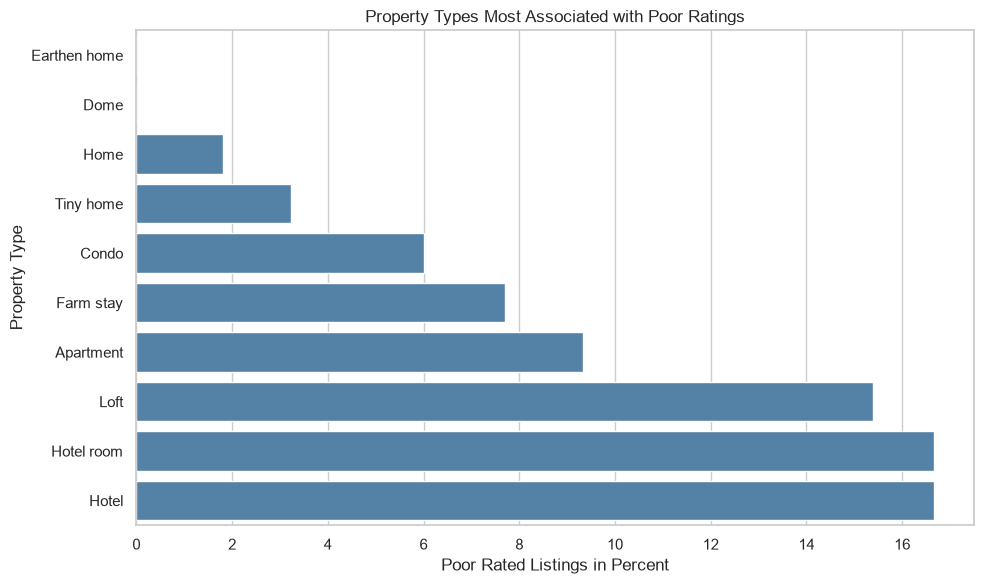

In [26]:
plt.figure(figsize=(10, 6))

plot_data = (
    poor_property_types
    .head(10)
    .sort_values("Poor_Rating_Percentage")
)

sns.barplot(
    data=plot_data.reset_index(),
    x="Poor_Rating_Percentage",
    y="Property Type",
    color="steelblue"
)

plt.title("Property Types Most Associated with Poor Ratings")
plt.xlabel("Poor Rated Listings in Percent")
plt.ylabel("Property Type")

plt.tight_layout()
plt.show()

In [ ]:
#RQ10 Result: Hosts should prioritize the overall guest experience rather than simply increasing the number of amenities. The analysis found that amenities mentioned had only a very weak relationship with guest ratings, while ratings differed significantly across locations and certain property types showed higher proportions of poorly rated listings. Hotel rooms, hotels, lofts, and apartments showed the highest proportions of low rated properties in the dataset. Hosts operating these property types should therefore pay particular attention to factors affecting the guest experience and expectations.


#Conclusion: To improve poorly rated listings, hosts should prioritize service quality, property condition, cleanliness, accuracy of listing information, and management of guest expectations rather than relying solely on adding amenities. Location cannot easily be changed, but hosts can improve how the property is positioned and priced relative to its market. Amenities should support the guest experience, but the analysis does not show that simply mentioning more amenities produces better ratings.

In [ ]:
Recommendations
RQ1	Focus improvement efforts on the small group of low rated listings while maintaining the strong performance of highly rated properties.
RQ2	Avoid relying on price changes alone to improve ratings. Focus on delivering value that matches the price guests pay.
RQ3	Prioritize quality improvements in hotels, hotel rooms, lofts, and apartments, which showed greater exposure to poor ratings.
RQ4	Use amenities strategically to support pricing, but do not rely on amenities alone since their relationship with price was weak.
RQ5	Focus on the quality and usefulness of amenities rather than simply increasing or advertising more amenities.
RQ6	Adapt service standards and listing strategies to local guest expectations because ratings differed significantly by location.
RQ7	Set prices according to local market conditions since location showed a significant relationship with Airbnb prices.
RQ8	Closely monitor guest feedback as review volume increases and address recurring concerns before they affect overall ratings.
RQ9	Consider seasonal patterns when planning pricing and operations, but interpret months with very few listings cautiously.
RQ10	Prioritize guest experience, property quality, accurate listing information, appropriate pricing, and expectation management to improve poorly rated listings.

Overall Recommendation

Airbnb hosts should prioritize guest experience and value for money, adapt pricing and service strategies to their location and property type, and actively use guest feedback to identify areas for improvement. Amenities can support the offering, but they should not replace consistent service quality and accurate guest expectations.

In [ ]:
airbnb.to_csv("airbnb_cleaned.csv", index=False)

print("airbnb_cleaned.csv saved successfully.")
print("Rows:", airbnb.shape[0])
print("Columns:", airbnb.shape[1])